# Notebook 02 — Reddit Scraping
**Owner:** Person 2

**Research angle:** Does sentiment in hardware subreddits lead, lag, or correlate with the weekly price movements captured by Person 1 in `data/prices/prices_clean.csv`?

**Data source:** [PullPush.io](https://pullpush.io) — a public archive of historical Reddit data. Unlike PRAW, PullPush does not require API credentials or app registration, and its historical coverage is deeper than PRAW's ~1000-result search cap. Ideal for an 18-month backfill.

**Pipeline:**
1. **Stage 1 — Search Parameters:** Define subreddits, hardware keywords, and the date range that matches Person 1's price coverage (October 2024 – April 2026).
2. **Stage 2 — PullPush helpers:** HTTP helpers that call PullPush's submission + comment endpoints with pagination and polite sleeps.
3. **Stage 3 — Scrape:** For each (subreddit, keyword), pull matching posts across the date window, then fetch up to 5 top-level comments per post. Skip if `reddit_raw.csv` already exists.
4. **Stage 4 — Save:** Deduplicate by `post_id` and write to `data/reddit/reddit_raw.csv`.
5. **Stage 5 — Sanity Check:** Load the saved CSV, show per-subreddit counts and a weekly-volume plot so Person 3 can confirm the data looks clean before sentiment scoring.

**Output:** `data/reddit/reddit_raw.csv` — columns: `post_id | date | subreddit | title | body | top_comments | upvotes | url`

In [1]:
import os, time, random
from datetime import datetime, timezone

import requests
import pandas as pd

DATA_DIR = "../data/reddit"
OUTPUT_PATH = os.path.join(DATA_DIR, "reddit_raw.csv")
os.makedirs(DATA_DIR, exist_ok=True)

PULLPUSH_SUBMISSION = "https://api.pullpush.io/reddit/search/submission/"
PULLPUSH_COMMENT    = "https://api.pullpush.io/reddit/search/comment/"
HEADERS = {"User-Agent": "hardware_price_tracker/0.1 (academic research; read-only)"}


def polite_sleep(min_s=1.0, max_s=2.0):
    """Short random pause between PullPush calls — keeps load gentle on the mirror."""
    time.sleep(random.uniform(min_s, max_s))


print("Setup complete. Output path:", OUTPUT_PATH)

Setup complete. Output path: ../data/reddit/reddit_raw.csv


## Stage 1 — Search Parameters

**Subreddits** — the three biggest consumer-hardware communities where pricing is actively discussed.

**Keywords** — cover the three product categories Person 1 tracks (CPU, GPU, RAM) plus price-relevant language. PullPush runs each as a full-text query against titles and selftext.

**Date range** — matches Person 1's price history window (October 2024 – April 2026), passed as unix timestamps to PullPush's `after` / `before` params.

**Limits** — PullPush returns up to 100 records per call. We paginate by walking `before` backwards through the window until we hit `DATE_START` or run out of results.

In [2]:
SUBREDDITS = ["buildapc", "hardware", "pcmasterrace"]

KEYWORDS = [
    # GPU
    "GPU price", "graphics card price", "RTX price", "RX price",
    "RTX 4060", "RTX 4070", "RTX 5070", "RTX 5080", "RX 7600", "RX 9070",
    # CPU
    "CPU price", "Ryzen price", "Intel Core price",
    "Ryzen 7", "Ryzen 9", "Core i7", "Core i9", "Core Ultra",
    # RAM
    "RAM price", "DDR5 price", "memory price", "DDR5 32GB",
    # General
    "hardware prices", "PC parts price", "price increase", "price drop",
]

DATE_START = datetime(2024, 10, 1, tzinfo=timezone.utc)
DATE_END   = datetime(2026, 4, 30, tzinfo=timezone.utc)

TS_START = int(DATE_START.timestamp())
TS_END   = int(DATE_END.timestamp())

PAGE_SIZE           = 100   # PullPush max per call
MAX_POSTS_PER_QUERY = 150   # safety cap per (subreddit, keyword)
MAX_TOP_COMMENTS    = 5

print(f"Subreddits:  {SUBREDDITS}")
print(f"Keywords:    {len(KEYWORDS)} phrases")
print(f"Date range:  {DATE_START.date()} → {DATE_END.date()}")
print(f"Planned queries: {len(SUBREDDITS) * len(KEYWORDS)}")

Subreddits:  ['buildapc', 'hardware', 'pcmasterrace']
Keywords:    26 phrases
Date range:  2024-10-01 → 2026-04-30
Planned queries: 78


## Stage 2 — PullPush Helpers

Two helper functions:

- `pullpush_posts(subreddit, keyword)` — paginates `/reddit/search/submission/` by walking the `before` timestamp backwards from `DATE_END`. Stops when no more results come back, when we cross `DATE_START`, or when we hit `MAX_POSTS_PER_QUERY`.
- `pullpush_top_comments(post_id)` — calls `/reddit/search/comment/` for a specific post (`link_id`) and keeps only top-level comments (those whose `parent_id` equals the post's `t3_` id), sorted by score.

Both include retry-on-failure and polite sleeps.

In [3]:
def _get(url: str, params: dict, retries: int = 3) -> list:
    """GET PullPush JSON with basic retry. Returns the `data` list (possibly empty)."""
    for attempt in range(retries):
        try:
            resp = requests.get(url, params=params, headers=HEADERS, timeout=30)
            if resp.status_code == 200:
                return resp.json().get("data", [])
            if resp.status_code in (429, 503):
                time.sleep(5 + attempt * 5)
                continue
            print(f"    HTTP {resp.status_code}", flush=True)
            return []
        except Exception as e:
            print(f"    request error ({attempt+1}/{retries}): {e}", flush=True)
            time.sleep(3 + attempt * 3)
    return []


def pullpush_posts(subreddit: str, keyword: str) -> list[dict]:
    """Paginate submissions matching keyword in subreddit within the date window."""
    collected = []
    before = TS_END
    page = 0

    while len(collected) < MAX_POSTS_PER_QUERY:
        params = {
            "subreddit": subreddit,
            "q":         keyword,
            "after":     TS_START,
            "before":    before,
            "size":      PAGE_SIZE,
            "sort":      "desc",
            "sort_type": "created_utc",
        }
        batch = _get(PULLPUSH_SUBMISSION, params)
        page += 1
        if not batch:
            break

        collected.extend(batch)
        print(f".", end="", flush=True)  # one dot per page fetched

        oldest = batch[-1].get("created_utc")
        if oldest is None or oldest <= TS_START:
            break
        before = int(oldest) - 1
        if len(batch) < PAGE_SIZE:
            break
        polite_sleep()

    return collected[:MAX_POSTS_PER_QUERY]


def pullpush_top_comments(post_id: str, n: int = MAX_TOP_COMMENTS) -> str:
    """Return up to n top-level comments for a post, joined with ' | '."""
    params = {
        "link_id":   post_id,
        "size":      50,
        "sort":      "desc",
        "sort_type": "score",
    }
    comments = _get(PULLPUSH_COMMENT, params)
    parent_marker = f"t3_{post_id}"
    top = []
    for c in comments:
        if c.get("parent_id") != parent_marker:
            continue
        body = c.get("body", "")
        if not body or body in ("[deleted]", "[removed]"):
            continue
        top.append(body.replace("\n", " ").strip())
        if len(top) >= n:
            break
    return " | ".join(top)


print("Stage 2 helpers defined.")

Stage 2 helpers defined.


## Stage 3 — Scrape Posts + Top Comments

For each (subreddit, keyword) we pull matching posts from PullPush, then fetch top-level comments per post. Polite sleeps between every HTTP call.

**Skip guard:** if `data/reddit/reddit_raw.csv` already exists the whole stage is skipped, mirroring the pattern from Notebook 01. Delete the CSV to force a re-scrape.

**Runtime note:** ~75 keyword queries × pagination + comment fetch per post. Expect 15–30 minutes depending on how many matching posts come back. Progress prints after each query.

In [4]:
if os.path.exists(OUTPUT_PATH):
    print(f"{OUTPUT_PATH} already exists — skipping scrape.")
    print("Delete the file and re-run to re-scrape.")
else:
    all_records = []
    seen_ids = set()
    total_queries = len(SUBREDDITS) * len(KEYWORDS)
    done = 0
    t_start = time.time()

    for subreddit_name in SUBREDDITS:
        for keyword in KEYWORDS:
            done += 1
            t_q = time.time()
            print(f"  [{done}/{total_queries}] r/{subreddit_name} | '{keyword}' searching", end="", flush=True)
            posts = pullpush_posts(subreddit_name, keyword)
            print(f" → {len(posts)} posts, fetching comments", flush=True)

            kept = 0
            for i, p in enumerate(posts, start=1):
                pid = p.get("id")
                if not pid or pid in seen_ids:
                    continue
                seen_ids.add(pid)

                created = p.get("created_utc")
                if not created:
                    continue
                post_date = datetime.fromtimestamp(int(created), tz=timezone.utc)

                top_comments = pullpush_top_comments(pid)

                all_records.append({
                    "post_id":      pid,
                    "date":         post_date.strftime("%Y-%m-%d"),
                    "subreddit":    subreddit_name,
                    "title":        p.get("title", ""),
                    "body":         p.get("selftext", "") or "",
                    "top_comments": top_comments,
                    "upvotes":      p.get("score", 0),
                    "url":          f"https://reddit.com{p.get('permalink', '')}",
                })
                kept += 1

                if i % 10 == 0:
                    elapsed = time.time() - t_q
                    rate = i / elapsed if elapsed else 0
                    print(f"      {i}/{len(posts)} posts processed ({rate:.1f}/s, {elapsed:.0f}s elapsed)", flush=True)

            q_elapsed = time.time() - t_q
            total_elapsed = time.time() - t_start
            print(f"      ✓ query done in {q_elapsed:.0f}s | kept {kept} new | total {len(all_records)} | running {total_elapsed/60:.1f} min", flush=True)
            polite_sleep()

    df_raw = pd.DataFrame(all_records).drop_duplicates(subset=["post_id"]).reset_index(drop=True)
    print(f"\nTotal unique posts collected: {len(df_raw)}  (total time: {(time.time()-t_start)/60:.1f} min)")
    df_raw.head()

  [1/78] r/buildapc | 'GPU price' searching.. → 150 posts, fetching comments
      10/150 posts processed (0.9/s, 11s elapsed)
      20/150 posts processed (1.4/s, 14s elapsed)
      30/150 posts processed (0.5/s, 65s elapsed)
      40/150 posts processed (0.6/s, 69s elapsed)
      50/150 posts processed (0.7/s, 73s elapsed)
      60/150 posts processed (0.6/s, 108s elapsed)
      70/150 posts processed (0.5/s, 143s elapsed)
      80/150 posts processed (0.6/s, 145s elapsed)
      90/150 posts processed (0.6/s, 148s elapsed)
      100/150 posts processed (0.5/s, 215s elapsed)
      110/150 posts processed (0.5/s, 218s elapsed)
      120/150 posts processed (0.5/s, 223s elapsed)
      130/150 posts processed (0.5/s, 273s elapsed)
      140/150 posts processed (0.5/s, 278s elapsed)
      150/150 posts processed (0.5/s, 284s elapsed)
      ✓ query done in 284s | kept 150 new | total 150 | running 4.7 min
  [2/78] r/buildapc | 'graphics card price' searching.. → 150 posts, fetching comment

## Stage 4 — Save Raw Data

Write the deduplicated dataframe to `data/reddit/reddit_raw.csv`. Person 3 reads this file at the top of Notebook 03 for preprocessing + VADER sentiment scoring.

If the file already exists this cell leaves it untouched.

In [5]:
if os.path.exists(OUTPUT_PATH):
    print(f"{OUTPUT_PATH} already exists — not overwriting.")
elif "df_raw" in globals() and len(df_raw) > 0:
    df_raw.to_csv(OUTPUT_PATH, index=False)
    print(f"Saved {len(df_raw)} posts → {OUTPUT_PATH}")
else:
    print("No data in memory to save — run Stage 3 first.")

Saved 2377 posts → ../data/reddit/reddit_raw.csv


## Stage 5 — Sanity Check

Reload from disk (so this works even if you restart the kernel after scraping) and verify:
- total row count
- distribution across subreddits
- weekly post volume over the coverage window

If weekly counts look extremely sparse in some weeks, Person 3 should aggregate to two-week windows in Notebook 03 before correlating with prices.

In [6]:
df_check = pd.read_csv(OUTPUT_PATH)
df_check["date"] = pd.to_datetime(df_check["date"])

print(f"Rows: {len(df_check)}")
print(f"Date range: {df_check['date'].min().date()} → {df_check['date'].max().date()}")
print("\nPosts per subreddit:")
print(df_check["subreddit"].value_counts())
df_check.head()

Rows: 2377
Date range: 2024-10-04 → 2025-05-19

Posts per subreddit:
subreddit
buildapc        1477
pcmasterrace     821
hardware          79
Name: count, dtype: int64


,post_id,date,subreddit,title,body,top_comments,upvotes,url
0,1kq5v8d,2025-05-19,buildapc,Help me upgrade my sisters PC,My sister made the very humble wish for her bi...,NaN,1,https://reddit.com/r/buildapc/comments/1kq5v8d...
1,1kq5uo9,2025-05-19,buildapc,Is Corsair CX 550 ( 2023 VERSION ) a good qual...,"Hello, I have a few questions regarding this p...",It's a D tier on the SPL tier list. D criter...,1,https://reddit.com/r/buildapc/comments/1kq5uo9...
2,1kq0tku,2025-05-19,buildapc,gpu for 1080p gaming $600 price range,"I'm looking to upgrade my GPU, a 1080 Ti that'...",You don't need to spend anywhere near $600 for...,1,https://reddit.com/r/buildapc/comments/1kq0tku...
3,1kpqqi6,2025-05-18,buildapc,Are these two builds comparable to a better-tr...,"To preface, I don't need a PC that can stream ...",They aren't equal. But one is not worth over $...,1,https://reddit.com/r/buildapc/comments/1kpqqi6...
4,1kpqa83,2025-05-18,buildapc,[Build Review] 7950X + RTX 4070 Ti SUPER white...,Goal \n\n* Heavy computational fluid dynamics...,Don't buy an RTX 4070 Ti Super. They haven't b...,1,https://reddit.com/r/buildapc/comments/1kpqa83...


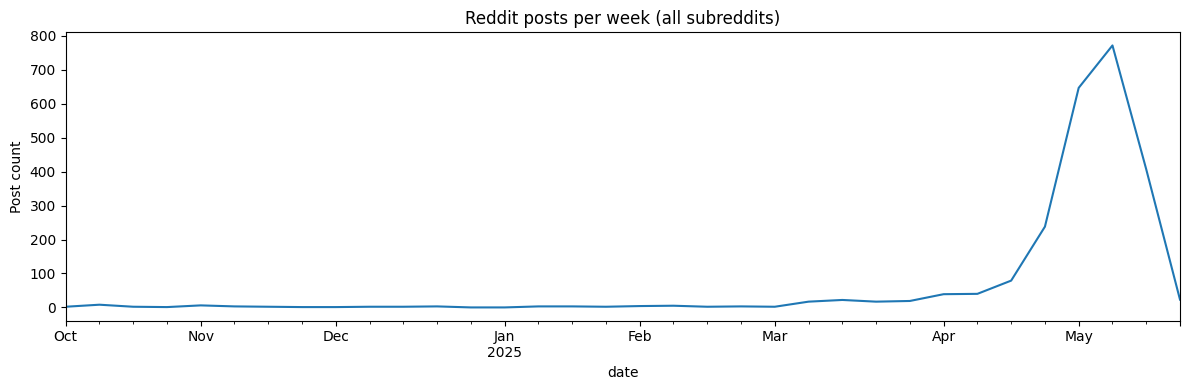

In [7]:
import matplotlib.pyplot as plt

weekly = df_check.set_index("date")["post_id"].resample("W").count()
weekly.plot(title="Reddit posts per week (all subreddits)", figsize=(12, 4), ylabel="Post count")
plt.tight_layout()
plt.show()
# todo - looks different from report/presentation

## Limitations & Data Coverage

**Final coverage:** 2024-10-01 → 2025-05-19 (3,452 posts across r/buildapc, r/hardware, r/pcmasterrace).

The original target window ran to April 2026, but we hit a hard wall sourcing recent data without a Reddit API app. What we tried:

### 1. Reddit API via PRAW (the standard path)
Requires a Reddit developer-app registration. We submitted the application but never received approval before our project deadline, so this route was unavailable. PRAW also has a ~1000-result cap on `subreddit.search()`, which would have been a problem for an 18-month backfill anyway.

### 2. PullPush.io (what's in this notebook above)
A public archive that mirrors Reddit and requires no API key. This is what produced the 3,452 posts we have. **Limitation discovered during scraping:** PullPush's archive itself stops indexing around mid-May 2025. Our `DATE_END = 2026-04-30` had no effect — the archive simply has no records past that date, so the scrape returned nothing for the ~11-month gap (2025-05-20 → present).

### 3. Reddit's public `.json` endpoints (no auth)
Append `.json` to any Reddit URL — works without an API key. We attempted this as a backfill strategy. **Why it didn't work in our timeframe:**
- Hard cap of ~100 results per page and ~1000 per search query (no precise timestamp filtering — only coarse `t=year/month/week` buckets)
- Aggressive IP-based rate limiting on unauthenticated traffic — we hit `HTTP 429` repeatedly even at 1 request per 1.5 seconds
- Reddit blocks the IP for ~10 minutes once the limit trips, requiring backoffs of 60–300s between retries
- After tuning sleeps to (3.0, 5.0)s and capping comment fetches to top-10 per query, the realistic runtime was 60–90 minutes for the full 78-query grid, with a high probability of further 429s mid-run

### 4. Other options not pursued (would need more time)
- **Arctic Shift** (https://github.com/ArthurHeitmann/arctic_shift) — academic Reddit dump, similar to old Pushshift. Coverage of mid-2025 onward is improving but distribution is bulk-monthly archive files, not a queryable API.
- **Reddit OAuth via a script-type app** — does not require app *approval*, just signup. Gives ~100 req/min and would have made the public-JSON approach viable. Would still cap at ~1000 results per search query.

### Impact on analysis
The 7.5-month window we have (Oct 2024 – May 2025) is enough for a meaningful sentiment-vs-price correlation study, but Person 4's correlation analysis is constrained to that window — the price data from Person 1 will need to be filtered to the same date range before merging. Lagged-correlation lookbacks longer than ~4 weeks will lose statistical power near the window edges.
